## Capstone 2: Business Analysis with Python

This notebook analyzes sales performance for EmporiUm, a fictional student bookstore chain.

The purpose of this project is to compare sales performance between the Florida and South Carolina sales territories in the South region using Python, pandas, and Matplotlib.



In [3]:
import pandas as pd
import matplotlib.pyplot as plt 

In [4]:
#Loading/Checking the store sales file 
store_sales = pd.read_csv('StoreSales.csv')

store_sales.info()

store_sales.head()


<class 'pandas.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  str    
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  str    
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), str(2)
memory usage: 12.8 MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [5]:
#Loading/Checking the products csv file 
products = pd.read_csv('Products.csv')

products.info()

products.head()



<class 'pandas.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Prod Num       669 non-null    str  
 1   Product        669 non-null    str  
 2   CategoryID     669 non-null    int64
 3   SubcategoryID  669 non-null    str  
dtypes: int64(1), str(3)
memory usage: 21.0 KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


In [6]:
#Loading/Checking the Product Categories File 
product_categories = pd.read_csv('ProductCategories.csv')

product_categories.info()

product_categories.head()



<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CategoryID     52 non-null     int64
 1   Category       52 non-null     str  
 2   SubcategoryID  52 non-null     str  
 3   Subcategory    52 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.8 KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [7]:
#Loading/Checking the Store Detail File 
store_detail = pd.read_csv('StoreDetail.csv')

store_detail.info()

store_detail.head()

<class 'pandas.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Store Location     111 non-null    str  
 1   State              111 non-null    str  
 2   Store ID           111 non-null    int64
 3   Territory Manager  111 non-null    str  
 4   Region             111 non-null    str  
 5   Region Director    111 non-null    str  
dtypes: int64(1), str(5)
memory usage: 5.3 KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [8]:
#Loading/Checking the customer_list file 
customer_list = pd.read_csv(
    'customer_list.csv',
    sep='|'
)
customer_list.info()

customer_list.head()

<class 'pandas.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   cust_id       521 non-null    int64
 1   date          521 non-null    str  
 2   time          521 non-null    str  
 3   name          521 non-null    str  
 4   email         521 non-null    str  
 5   phone         520 non-null    str  
 6   sms-opt-out   520 non-null    str  
dtypes: int64(1), str(6)
memory usage: 28.6 KB


,cust_id,date,time,name,email,phone,sms-opt-out
0,1,2023-03-15,08:45:12,Rachel,rachel@centralperk.coffee,212-555-1001,N
1,2,2023-05-22,12:30:45,R. Geller,rossg@centralperk.coffee,212-555-1002,N
2,3,2023-07-09,18:15:27,Monica Geller,chefmonica@centralperk.coffee,212-555-1003,N
3,4,2023-09-01,21:05:33,Chandler Bing,chandlerb@centralperk.coffee,212-555-1004,Y
4,5,2023-11-18,14:22:10,Joey,howyoudoing@centralperk.coffee,212-555-1005,N


In [9]:
#Merging StoreSales with StoreDetail using StoreID
sales_with_stores = pd.merge(
    store_sales,
    store_detail,
    on='Store ID'
)

sales_with_stores.head()

#This connects each sale to the store’s location, state, territory manager, and region.

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director
0,1/1/2022,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers
1,1/1/2022,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers
2,1/1/2022,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers
3,1/1/2022,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers
4,1/1/2022,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers


In [10]:
#Merging Sales/Store data with Products using Prod Num
sales_with_products = pd.merge(
    sales_with_stores,
    products,
    on='Prod Num'
)

sales_with_products.head()
#This connects each sale to the product name and product category IDs. 

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Product,CategoryID,SubcategoryID
0,1/1/2022,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Gel Pen (Pack of 2),130,130-off
1,1/1/2022,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,Corporate Finance,100,100-bus
2,1/1/2022,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Classic Cotton T-Shirt (White),130,130-clo
3,1/1/2022,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,"LTCA Year Up Power Bank (10,000mAh)",130,130-tec
4,1/1/2022,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,Newsprint Paper Pad (18x24 inches),115,115-ske


In [11]:
# Merge SALES/STORE/PRODUCT Data with ProductCategories
full_sales_data = pd.merge(
    sales_with_products,
    product_categories,
    on=['CategoryID', 'SubcategoryID']
)

full_sales_data.head()

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,Product,CategoryID,SubcategoryID,Category,Subcategory
0,1/1/2022,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Gel Pen (Pack of 2),130,130-off,Apparel and Merchandise,Office and Study Supplies
1,1/1/2022,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,Corporate Finance,100,100-bus,Textbooks,Business & Economics
2,1/1/2022,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,LTCA Year Up Classic Cotton T-Shirt (White),130,130-clo,Apparel and Merchandise,"Clothing (T-Shirts, Hoodies, and Jackets)"
3,1/1/2022,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,"LTCA Year Up Power Bank (10,000mAh)",130,130-tec,Apparel and Merchandise,Technology Accessories
4,1/1/2022,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,Newsprint Paper Pad (18x24 inches),115,115-ske,Art Supplies,Sketchbooks and Paper


In [12]:
#Now we merge all of that with Customer Data as well 
full_sales_data = pd.merge(
    full_sales_data,
    customer_list,
    left_on='RewardsID',
    right_on='cust_id',
    how='left'
)

full_sales_data.head()

#Now we have created on giant table containing all of the information given. 

,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,...,SubcategoryID,Category,Subcategory,cust_id,date,time,name,email,phone,sms-opt-out
0,1/1/2022,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,...,130-off,Apparel and Merchandise,Office and Study Supplies,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1/1/2022,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,...,100-bus,Textbooks,Business & Economics,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1/1/2022,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,130-clo,Apparel and Merchandise,"Clothing (T-Shirts, Hoodies, and Jackets)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1/1/2022,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,130-tec,Apparel and Merchandise,Technology Accessories,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1/1/2022,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,115-ske,Art Supplies,Sketchbooks and Paper,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Core Marketing Analysis

### Request 1: Who are the territory managers? What stores belong to each territory and provide their information. 

In [13]:
# Filter for Florida and South Carolina only
south_territories = full_sales_data[
    full_sales_data['State'].isin(['Florida', 'South Carolina'])
]

# Display territory information
south_territories[
    [
        'State',
        'Store ID',
        'Store Location',
        'Territory Manager',
        'Region'
    ]
].drop_duplicates().sort_values(
    by=['State', 'Store ID']
)
#Dropping duplicates to make sure only one row per store 

,State,Store ID,Store Location,Territory Manager,Region
23,Florida,719,Cape Canaveral,Lana Ilana,South
170,Florida,720,Fort Lauderdale,Lana Ilana,South
24,Florida,721,Jacksonville,Lana Ilana,South
173,Florida,722,Key West,Lana Ilana,South
25,Florida,723,Lakeland,Lana Ilana,South
27,Florida,724,Miami,Lana Ilana,South
177,Florida,725,Naples,Lana Ilana,South
29,Florida,726,Orlando,Lana Ilana,South
30,Florida,727,Sebring,Lana Ilana,South
31,Florida,728,Tallahassee,Lana Ilana,South


The South region territories analyzed in this project include Florida and South Carolina.

Florida stores are managed by Lana Ilana, while South Carolina stores are managed by Len Jensen.

The table above identifies the store IDs and store locations associated with each territory in the South region.

### Request 2: What is the monthly total revenue for in-store sales in each territory? 

In [14]:
# Convert Transaction Date into datetime format
full_sales_data['Transaction Date'] = pd.to_datetime(
    full_sales_data['Transaction Date']
)

# Create a month column
full_sales_data['Month'] = full_sales_data[
    'Transaction Date'
].dt.to_period('M')

# Preview updated dataframe
full_sales_data.head()


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Store Location,State,Territory Manager,Region,Region Director,...,Category,Subcategory,cust_id,date,time,name,email,phone,sms-opt-out,Month
0,2022-01-01,702,NaN,105349-M,8.00,Berthoud,Colorado,Jim Heck,West,Cassie Chambers,...,Apparel and Merchandise,Office and Study Supplies,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01
1,2022-01-01,704,NaN,105350-T,144.00,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers,...,Textbooks,Business & Economics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01
2,2022-01-01,705,NaN,105351-M,44.00,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,Apparel and Merchandise,"Clothing (T-Shirts, Hoodies, and Jackets)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01
3,2022-01-01,705,NaN,105352-M,47.61,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,Apparel and Merchandise,Technology Accessories,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01
4,2022-01-01,705,NaN,105353-A,20.36,Denver,Colorado,Jim Heck,West,Cassie Chambers,...,Art Supplies,Sketchbooks and Paper,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-01


In [15]:
# Filter for Florida and South Carolina
south_sales = full_sales_data[
    full_sales_data['State'].isin(
        ['Florida', 'South Carolina']
    )
]

# Group by state and month
monthly_revenue = south_sales.groupby(
    ['State', 'Month']
)['Sale Amount'].sum().reset_index()

# Preview results
monthly_revenue.head()


,State,Month,Sale Amount
0,Florida,2022-01,48634.02
1,Florida,2022-02,46423.67
2,Florida,2022-03,53994.93
3,Florida,2022-04,49912.28
4,Florida,2022-05,58827.96


The monthly revenue analysis shows the total in-store sales revenue generated in Florida and South Carolina over time.

By grouping sales transactions by state and month, we can identify sales trends and compare territory performance throughout the reporting period.

This analysis helps identify seasonal patterns, high-performing periods, and potential opportunities for marketing focus.

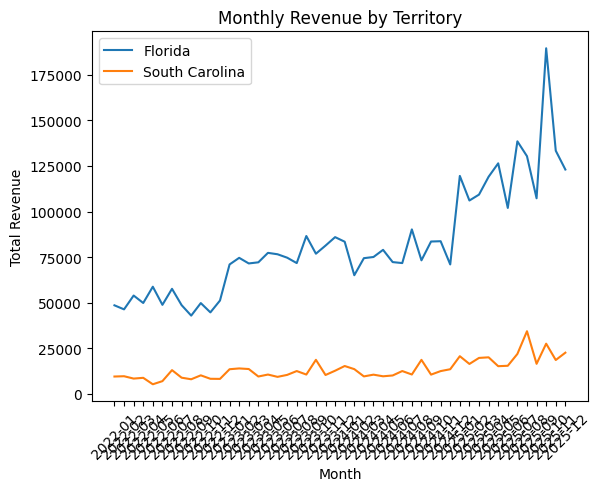

In [16]:
# Create a line chart for monthly revenue

for state in monthly_revenue['State'].unique():

    state_data = monthly_revenue[
        monthly_revenue['State'] == state
    ]

    plt.plot(
        state_data['Month'].astype(str),
        state_data['Sale Amount'],
        label=state
    )

# Add chart title and labels
plt.title('Monthly Revenue by Territory')

plt.xlabel('Month')

plt.ylabel('Total Revenue')

# Rotate month labels
plt.xticks(rotation=45)

# Show legend
plt.legend()

# Display chart
plt.show()

The line chart above compares monthly sales revenue trends between Florida and South Carolina.

Florida generally generated stronger sales performance throughout the reporting period, while South Carolina maintained lower but more consistent revenue levels.

Visualizing the data over time makes it easier to identify trends, seasonal changes, and differences in territory performance.

### Request 3: Rank the sales performance of each store in each territory. Which are the top-performing stores?

In [17]:
# Rank stores by total sales revenue in each territory
store_performance = south_sales.groupby(
    ['State', 'Store ID', 'Store Location']
)['Sale Amount'].sum().reset_index()

# Sort by state and highest sales amount
store_performance = store_performance.sort_values(
    by=['State', 'Sale Amount'],
    ascending=[True, False]
)

store_performance

,State,Store ID,Store Location,Sale Amount
5,Florida,724,Miami,622317.68
9,Florida,728,Tallahassee,544922.08
3,Florida,722,Key West,333867.47
0,Florida,719,Cape Canaveral,333461.15
2,Florida,721,Jacksonville,332842.25
8,Florida,727,Sebring,332282.31
10,Florida,729,Tampa,310240.62
1,Florida,720,Fort Lauderdale,304651.03
7,Florida,726,Orlando,298878.03
4,Florida,723,Lakeland,275350.42


In [20]:
# Show the top 5 stores in each territory
top_stores = store_performance.groupby('State').head(5)

top_stores

,State,Store ID,Store Location,Sale Amount
5,Florida,724,Miami,622317.68
9,Florida,728,Tallahassee,544922.08
3,Florida,722,Key West,333867.47
0,Florida,719,Cape Canaveral,333461.15
2,Florida,721,Jacksonville,332842.25
12,South Carolina,853,Greenville,338633.07
11,South Carolina,852,Charleston,314087.99


The table above ranks stores by total sales revenue in each assigned territory.

The top-performing stores are the locations with the highest total sales revenue. These stores may be strong candidates for continued marketing investment because they are already generating high sales.

### Request 4: Find the top customers in each sales territory based off of customerID and rewardsID. 

In [23]:
# Remove rows with missing RewardsID values
customer_sales = south_sales.dropna(
    subset=['RewardsID']
)

# Group by customer and state
top_customers = customer_sales.groupby(
    ['State', 'RewardsID', 'name']
)['Sale Amount'].sum().reset_index()

# Sort highest to lowest sales
top_customers = top_customers.sort_values(
    by=['State', 'Sale Amount'],
    ascending=[True, False]
)

top_customers.head(10)

,State,RewardsID,name,Sale Amount
45,Florida,47.0,Stanley H.,4954.99
257,Florida,259.0,Todd Chavez,4549.16
188,Florida,190.0,Huck,4427.90
333,Florida,335.0,John Locke,3631.94
162,Florida,164.0,Dr. Ray Flemming,3535.88
416,Florida,418.0,Ernie,3387.58
54,Florida,56.0,Leslie Knope,3355.68
141,Florida,143.0,Billy Abbott,3334.54
213,Florida,215.0,Lisa W.,3240.71
210,Florida,212.0,Geoffrey,3225.15


In [24]:
# Display top 5 customers per territory
top_5_customers = top_customers.groupby(
    'State'
).head(5)

top_5_customers

,State,RewardsID,name,Sale Amount
45,Florida,47.0,Stanley H.,4954.99
257,Florida,259.0,Todd Chavez,4549.16
188,Florida,190.0,Huck,4427.90
333,Florida,335.0,John Locke,3631.94
162,Florida,164.0,Dr. Ray Flemming,3535.88
706,South Carolina,340.0,Jin Kwon,1786.05
747,South Carolina,404.0,Roman Roy,1778.84
642,South Carolina,213.0,Jazz,1763.70
562,South Carolina,74.0,Ben Chang,1566.60
677,South Carolina,280.0,Cal Abar,1396.50


The analysis above identifies the highest-spending rewards customers in Florida and South Carolina.

Top customers contribute significant sales revenue and may represent loyal repeat shoppers. These customers could be targeted through loyalty rewards, promotions, and personalized marketing campaigns to encourage continued spending.

### Request 5: How many transactions of each product category are there each month? Whats the total sales revenue from each category every month?  What might this tell you about the most popular products, and where could there be opportunity for growth?

In [25]:
# Count transactions by month and category
category_transactions = south_sales.groupby(
    ['Month', 'Category']
).size().reset_index(name='Transaction Count')

# Preview results
category_transactions.head()


,Month,Category,Transaction Count
0,2022-01,Apparel and Merchandise,78
1,2022-01,Art Supplies,88
2,2022-01,Books (General),24
3,2022-01,Stationery and Supplies,76
4,2022-01,Technology & Accessories,88


In [26]:
# Total sales revenue by month and category
category_revenue = south_sales.groupby(
    ['Month', 'Category']
)['Sale Amount'].sum().reset_index()

# Preview results
category_revenue.head()

,Month,Category,Sale Amount
0,2022-01,Apparel and Merchandise,2237.89
1,2022-01,Art Supplies,2854.48
2,2022-01,Books (General),649.26
3,2022-01,Stationery and Supplies,730.67
4,2022-01,Technology & Accessories,40162.12


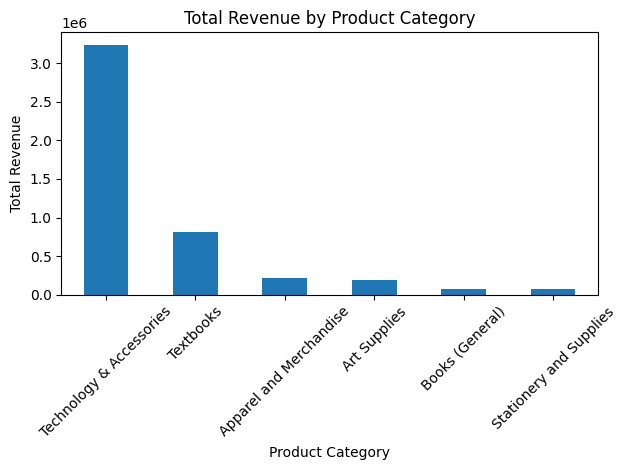

In [28]:
# Total revenue by category
total_category_revenue = south_sales.groupby(
    'Category'
)['Sale Amount'].sum().sort_values(
    ascending=False
)

# Create bar chart
total_category_revenue.plot(
    kind='bar'
)

# Add chart labels
plt.title('Total Revenue by Product Category')

plt.xlabel('Product Category')

plt.ylabel('Total Revenue')

# Rotate labels
plt.xticks(rotation=45)

#Improve readability 
plt.tight_layout()

# Display chart
plt.show()

The category analysis reveals which product categories generate the highest transaction volume and total sales revenue.

Categories with strong transaction counts indicate high customer demand and popularity. Categories generating high revenue may represent valuable products with strong profit potential.

Lower-performing categories may provide opportunities for targeted promotions, improved product placement, or expanded marketing efforts to increase customer engagement and sales growth.

### Request 6: What is your recommendation for where to focus marketing attention in the next quarter?

Based on the analysis performed throughout this project, the strongest opportunity for marketing focus next quarter appears to be within the Technology & Accessories category, particularly in high-performing Florida stores such as Miami and Tallahassee.

Technology products generated the highest total revenue across the assigned territories, indicating strong customer demand and high sales performance. Florida consistently outperformed South Carolina in monthly sales revenue, suggesting that additional promotional investment in high-performing Florida stores could continue driving strong returns.

South Carolina stores generated lower overall sales revenue, but Greenville demonstrated strong performance within the territory. Marketing efforts in South Carolina could focus on targeted promotions, customer loyalty campaigns, and category-specific advertising to encourage growth.

Additionally, the top rewards customers identified in the analysis represent valuable repeat shoppers. Personalized promotions and loyalty incentives may help increase customer retention and repeat purchases in both territories.